In [1]:
import sys
import os

#print(sys.modules)

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

workdir_ = '../'  #'/glade/work/juliob'
if ( workdir_ not in sys.path ):
    sys.path.append(workdir_)
    print( f" a path to {workdir_} added in {__name__} ")





 a path to ../ added in __main__ 


In [2]:
%%time

f, is_mpas = '/glade/derecho/scratch/juliob/archive/mpas_ndg_test02/atm/hist/mpas_ndg_test02.cam.h1i*.nc' , True
f, is_mpas = '/glade/derecho/scratch/juliob/archive/mpas_ndg_test03/atm/hist/mpas_ndg_test03.cam.h1i*.nc' , True

#f, is_mpas = '/glade/derecho/scratch/juliob/archive/ndg00_c6455g3/atm/hist/ndg00_c6455g3.cam.h1i.2014-06-*.nc' , False

X = xr.open_mfdataset(  f, combine='nested',
                            concat_dim='time',
                            data_vars='different',
                            coords='different' ) 

CPU times: user 1.9 s, sys: 315 ms, total: 2.21 s
Wall time: 5.61 s


In [3]:
#f='/glade/campaign/cgd/amp/juliob/ERA5/mpasa120_phys/L58_mpas/ERA5_x_mpasa120_L58_mpas_rgC2_WO.2001-*.nc'
#XE = xr.open_mfdataset(  f, combine='nested',concat_dim='time' ) 
        

In [4]:
u_targ=X.Target_U.values
u=X.U.values
#u_era=XE.U.values


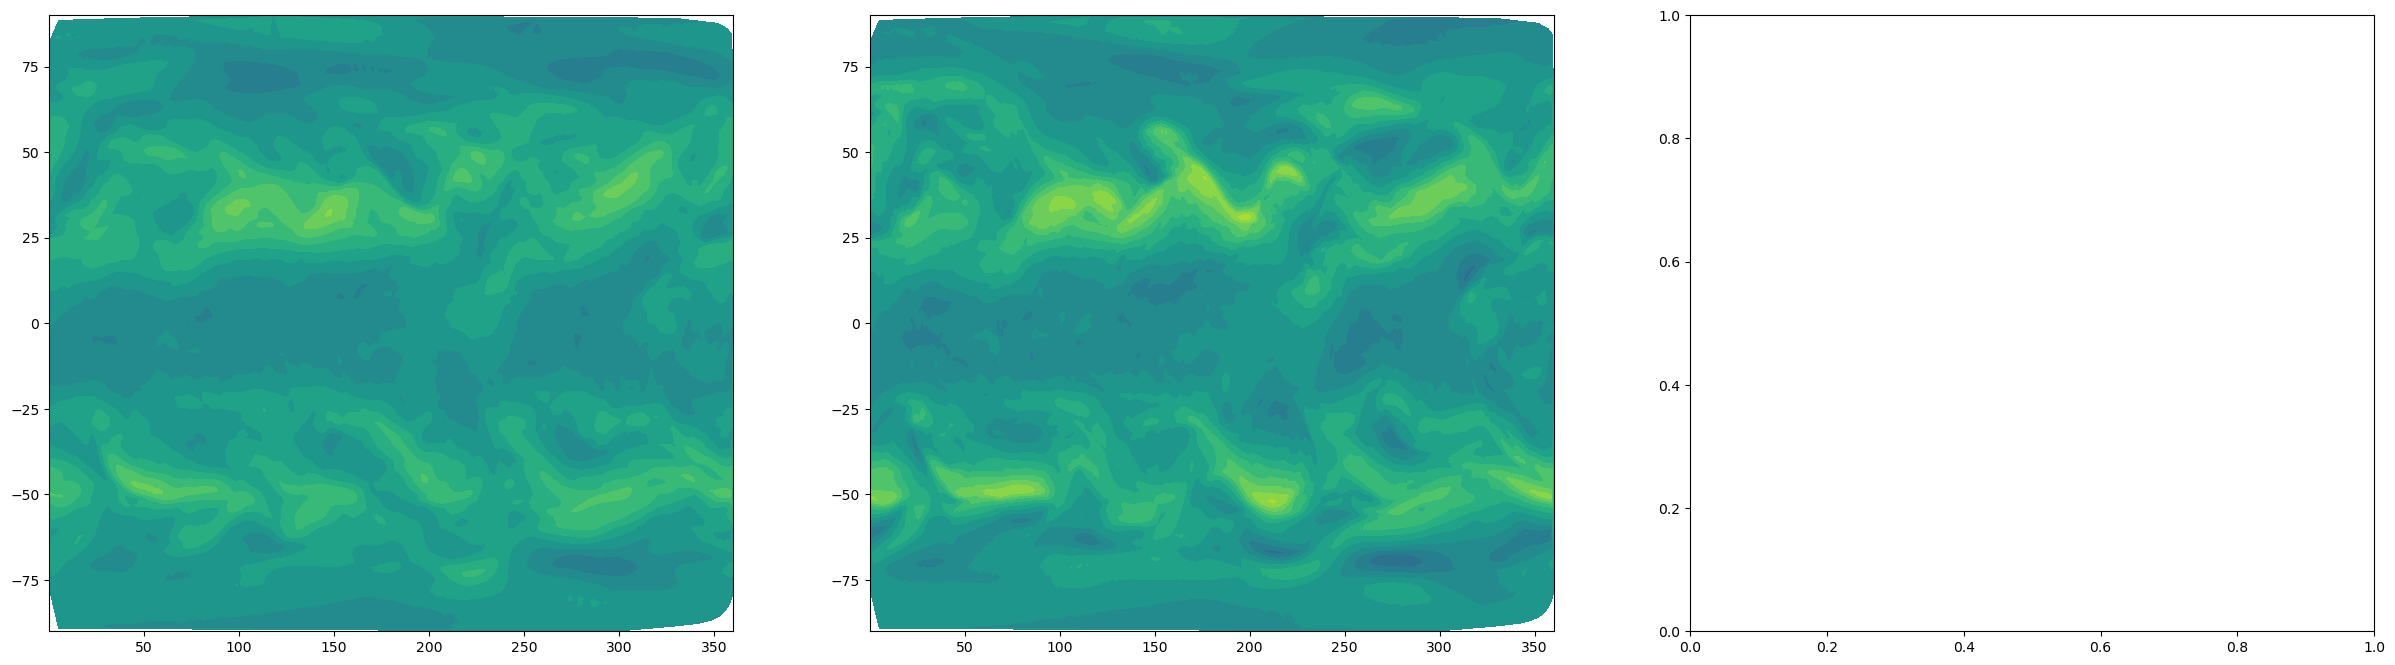

In [5]:
fig, ax = plt.subplots(1,3, figsize=(30, 8))
ax=ax.flatten()
lev=4*np.linspace(-30,30,21)
t,z=0,25
ax[0].tricontourf( X.lon ,X.lat ,u[t,z,:], levels=lev )
ax[1].tricontourf( X.lon ,X.lat ,u_targ[t,z,:], levels=lev )
#ax[2].tricontourf( X.lon ,X.lat ,u_era[t+1,z,:], levels=lev )

#ax.[1]plt.plot( u_targ[0,50,:] )


In [6]:

errsq=(u-u_targ)**2

uta=np.average( u , axis=0 )
utca=np.average( uta , axis=1)

print(np.shape(u))

nt,nz,ncol = np.shape(u)

(40, 58, 40962)


In [7]:
print(np.shape(utca))

udev=np.zeros( (nt, nz, ncol) )
for z in np.arange( nz ):
    udev[:,z,:] = u[:,z,:]-utca[z]

(58,)


In [8]:
udev_tz = np.sqrt( np.average( udev**2 , axis=2) )
err_tz = np.sqrt(np.average( errsq , axis=2 ))
err_zc = np.sqrt(np.average( errsq , axis=0 ))

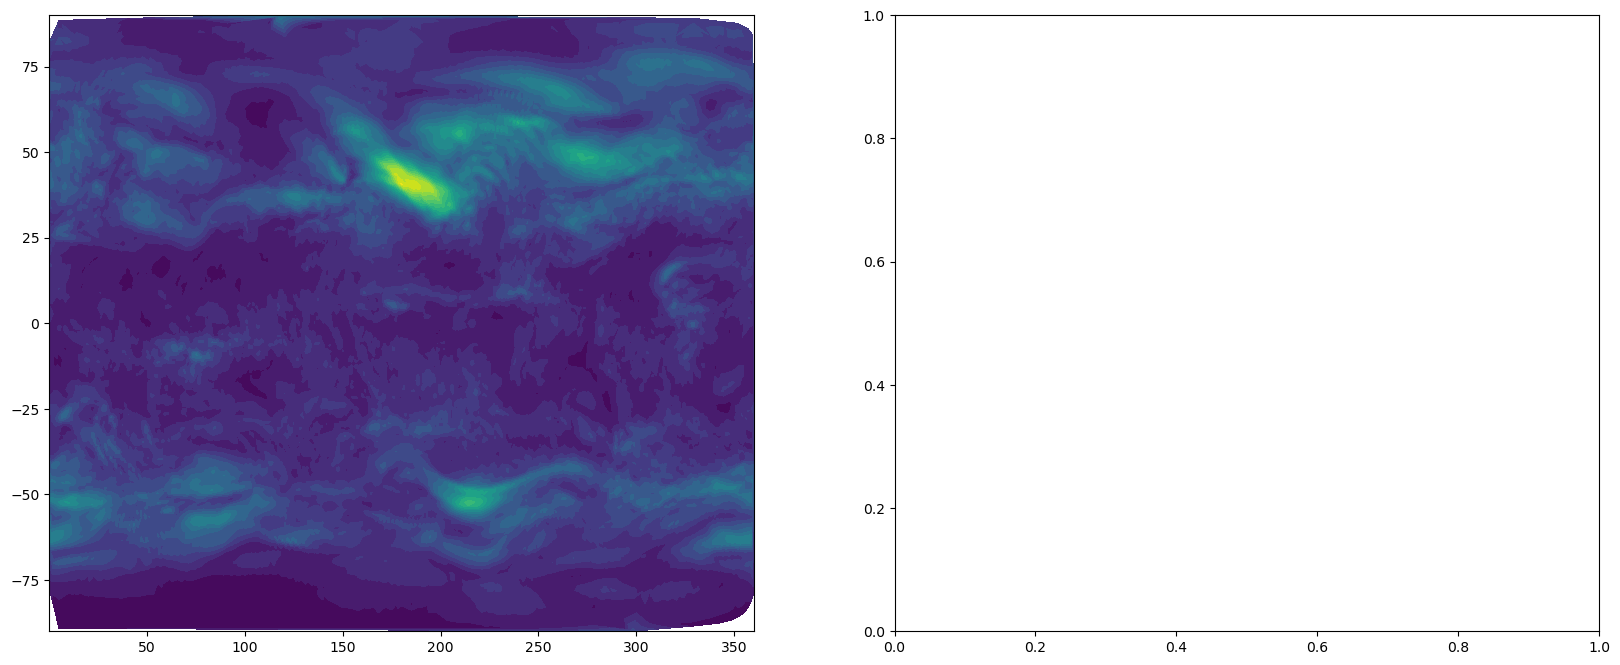

In [9]:
fig, ax = plt.subplots(1,2, figsize=(20, 8))
ax=ax.flatten()
lev=4*np.linspace(-30,30,21)
t,z=0,25
ax[0].tricontourf( X.lon ,X.lat ,err_zc[z,:], levels=21 )


Text(0.5, 1.0, ' At 9 km')

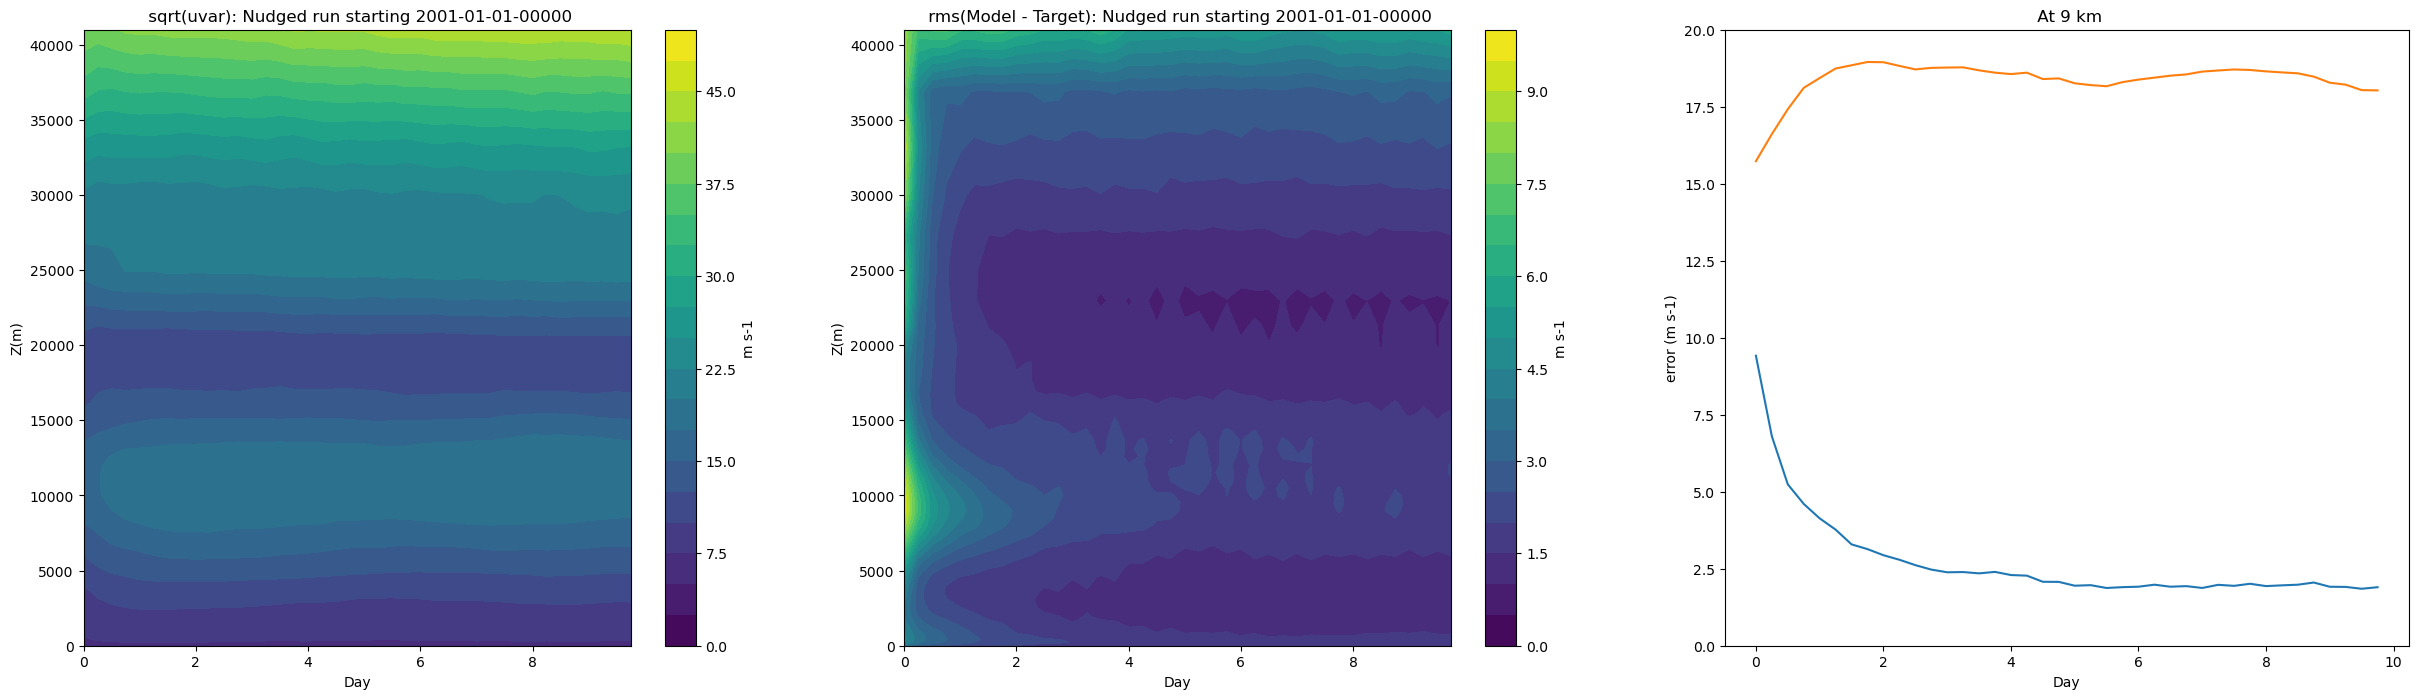

In [10]:
lev=np.linspace(0,10,num=21)
day=np.arange(nt)/4.

if (is_mpas == True):
    zz=X.lev.values
else:
    zz=-7000.0*np.log(X.lev.values/1_000.)
 

zog = np.abs(zz-9000.).argmin()
fig, ax = plt.subplots(1,3, figsize=(30, 8))
ax=ax.flatten()
#co=ax[0].contourf( day, zz, err_tz.T ,levels=lev )
co=ax[0].contourf( day, zz, udev_tz.T ,levels=5*lev )
ax[0].set_xlabel( 'Day' )
ax[0].set_ylabel( 'Z(m)' )
ax[0].set_title(' sqrt(uvar): Nudged run starting 2001-01-01-00000' )
ax[0].set_ylim(0,41_000)
plt.colorbar(co,label='m s-1')

co=ax[1].contourf( day, zz, err_tz.T ,levels=lev )
ax[1].set_xlabel( 'Day' )
ax[1].set_ylabel( 'Z(m)' )
ax[1].set_title(' rms(Model - Target): Nudged run starting 2001-01-01-00000' )
ax[1].set_ylim(0,41_000)
plt.colorbar(co,label='m s-1')

ax[2].plot( day, err_tz[:,zog] )
ax[2].plot( day, udev_tz[:,zog] )
ax[2].set_ylim(0,20)
ax[2].set_xlabel( 'Day' )
ax[2].set_ylabel( 'error (m s-1)' )
ax[2].set_title(' At 9 km' )



[4.11163687e+04 3.68719469e+04 3.32307995e+04 3.00325682e+04
 2.72744091e+04 2.49322040e+04 2.29648837e+04 2.13210067e+04
 1.99456395e+04 1.87859832e+04 1.77949989e+04 1.69330839e+04
 1.61682860e+04 1.54756253e+04 1.48360306e+04 1.42351956e+04
 1.36625218e+04 1.31102293e+04 1.25726468e+04 1.20456590e+04
 1.15262909e+04 1.10123973e+04 1.05024344e+04 9.99658917e+03
 9.49490412e+03 8.99490461e+03 8.49490510e+03 7.99490512e+03
 7.49490515e+03 6.99490517e+03 6.49490543e+03 5.99490569e+03
 5.49490545e+03 4.99490521e+03 4.49490523e+03 4.00445590e+03
 3.54819857e+03 3.14425277e+03 2.79091123e+03 2.47976609e+03
 2.20424266e+03 1.95910399e+03 1.74011272e+03 1.54379364e+03
 1.36726288e+03 1.20810248e+03 1.06426657e+03 9.34010195e+02
 8.15834228e+02 7.07112824e+02 6.05521027e+02 5.10307126e+02
 4.20778453e+02 3.36279248e+02 2.56161634e+02 1.79738310e+02
 1.06179976e+02 3.49999998e+01]


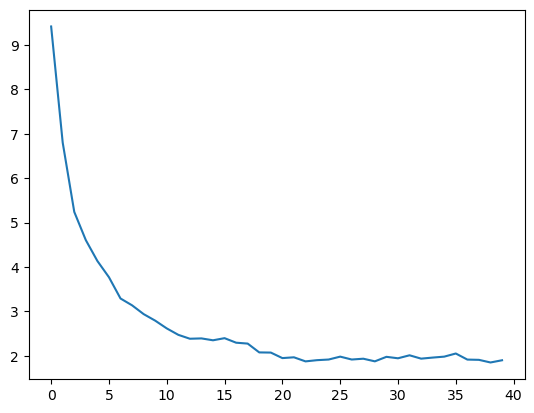

In [11]:
print(zz)
plt.plot(err_tz[:,25] )